In [ ]:
# Iris Classification using Logistic Regression

- Dataset: Built-in sklearn Iris dataset  
- Model: Logistic Regression  
- Accuracy: 100%  
- Cross-validation: ~99%  
- Includes decision boundary visualization

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [6]:
iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

df['Species'] = iris.target

df['Species'] = df['Species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'Species']

df.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
X = df.drop("Species", axis=1)
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [9]:
y_pred = model.predict(X_test)

In [10]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nAccuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Accuracy: 1.0


In [11]:
scores = cross_val_score(model, X_train, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Mean CV Score:", scores.mean())

Cross-validation scores: [0.95833333 1.         0.875      1.         0.95833333]
Mean CV Score: 0.9583333333333334


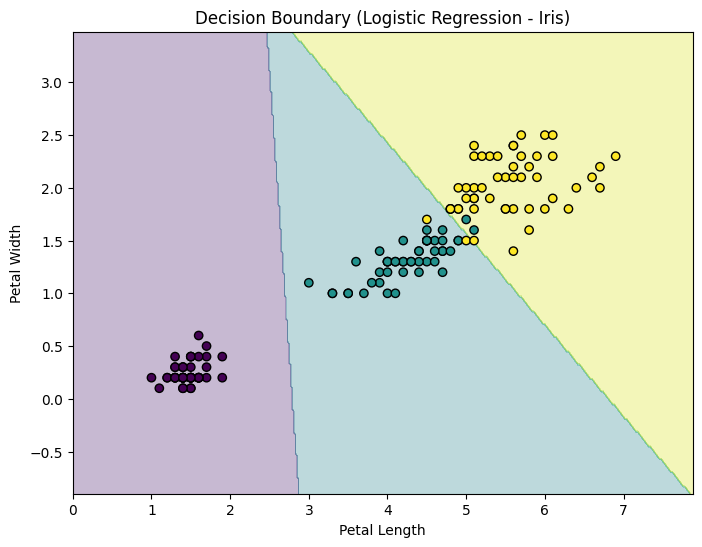

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

plt.figure(figsize=(8,6))  

X_vis = iris.data[:, [2, 3]]
y_vis = iris.target

model_vis = LogisticRegression()
model_vis.fit(X_vis, y_vis)

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolor='k')

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Boundary (Logistic Regression - Iris)")

plt.savefig("iris_plot.png") 